# `pycopykat` vs R `copykat` — real-tumour comparison (Lee2020_Colorectal / SMC16)

This notebook reads **pre-computed** outputs from the 17-patient
benchmark — no new runs are issued. R copykat on a 2,698-cell sample
takes ~22 minutes; the cached outputs let the comparison render in
seconds.

**Why this sample.** SMC16 is the one sample of the 17 where pycopykat
and R copykat disagree on the *majority class* (R: 83% diploid; py:
34% diploid), even though their bin-level CNA matrices agree closely.
Both runs trigger `unclassified.prediction` twice on the
`norm_cl → GMM` baseline-fallback chain. See
`benchmarks/full/FINDINGS.md → Known parity gap: Lee2020_Colorectal /
SMC16` and `benchmarks/full/TODO_parity_SMC16.md` for the open root-
cause investigation.

Switch sample by editing `CANCER` / `SAMPLE` in the next cell — any
subdirectory under `benchmarks/full/<cancer>/<sample>/` with the
standard `r_out/` + `py_out/` layout works.


In [1]:
from __future__ import annotations
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import omicverse as ov
import anndata as ad

import pycopykat
from pycopykat.viz import plot_cna_heatmap_compare, plot_cna_delta

ov.plot_set()
CANCER = 'Lee2020_Colorectal'
SAMPLE = 'SMC16'
SAMPLE_DIR = Path('/media/jason/T7/rerbulid/pycopykat/benchmarks/full/Lee2020_Colorectal/SMC16')
assert SAMPLE_DIR.exists(), f'sample dir missing: {SAMPLE_DIR}'
print('omicverse', ov.__version__, '— pycopykat', pycopykat.__version__)
print('reading cached outputs from:', SAMPLE_DIR)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA GeForce RTX 3070 Laptop GPU
      Memory: 7.8 GB | Compute: 8.6

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.8   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 1.7.8 — pycopykat 0.1.0.dev1
reading cached outputs from: /media/jason/T7/rerbulid/pycopykat/benchmarks/full/Lee2020_Colorectal/SMC16


## 1. Read cached outputs (no recomputation)

Files written by `scripts/run_r_copykat.R` and
`scripts/run_py_copykat.py` during the 17-patient benchmark.

In [2]:
tag = f'{SAMPLE}_full'
r_pred = pd.read_csv(SAMPLE_DIR / 'r_out' / f'{tag}_copykat_prediction.txt', sep='\t')
py_pred = pd.read_csv(SAMPLE_DIR / 'py_out' / f'{tag}_py_copykat_prediction.txt', sep='\t')
r_cna_raw = pd.read_csv(SAMPLE_DIR / 'r_out' / f'{tag}_copykat_CNA_results.txt', sep='\t')
py_cna_raw = pd.read_csv(SAMPLE_DIR / 'py_out' / f'{tag}_py_copykat_CNA_results.txt', sep='\t')
print('R prediction rows :', len(r_pred))
print('py prediction rows:', len(py_pred))
print('R CNA shape  (bins x meta+cells):', r_cna_raw.shape)
print('py CNA shape (bins x meta+cells):', py_cna_raw.shape)


R prediction rows : 2698
py prediction rows: 2695
R CNA shape  (bins x meta+cells): (12167, 2698)
py CNA shape (bins x meta+cells): (12167, 2698)


## 2. Normalise cell IDs and bin index

R `make.names()` rewrites `-` to `.` in cell IDs; py keeps the
original. Both sides share copykat's hg20 220-kb binning so we
align the CNA matrices by row order.

In [3]:
py_cells_set = set(py_pred['cell'])

def _to_py_cell(name: str) -> str:
    if name in py_cells_set: return name
    cand = name.replace('.', '-')
    return cand if cand in py_cells_set else name

r_pred = r_pred.rename(columns={'cell.names': 'cell'}).copy()
r_pred['cell'] = r_pred['cell'].map(_to_py_cell)

META_COLS = {'chrom', 'chrompos', 'abspos', 'start', 'end'}
def _strip_meta(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=[c for c in df.columns if c in META_COLS])

py_cna = _strip_meta(py_cna_raw)
r_cna  = _strip_meta(r_cna_raw).rename(columns=lambda c: _to_py_cell(c))

# Adopt py's bin axis (start_end multiindex if present, else range)
if py_cna.shape[0] == r_cna.shape[0]:
    if {'chrom', 'start', 'end'}.issubset(py_cna_raw.columns):
        py_cna.index = pd.MultiIndex.from_arrays(
            [py_cna_raw['chrom'], py_cna_raw['start']], names=['chrom', 'start'],
        )
        r_cna.index = py_cna.index
    else:
        py_cna.index = pd.RangeIndex(py_cna.shape[0])
        r_cna.index = py_cna.index
else:
    raise RuntimeError(f'bin counts differ: py={py_cna.shape[0]} R={r_cna.shape[0]}')

common_cells = sorted(set(py_pred['cell']) & set(r_pred['cell']))
common_cna = sorted(set(py_cna.columns) & set(r_cna.columns))
print('common cells (predictions):', len(common_cells))
print('common cells (CNA):       ', len(common_cna))


common cells (predictions): 2695
common cells (CNA):        2695


## 3. Class-distribution side-by-side

In [4]:
def _binarise(label: str) -> str:
    s = str(label)
    if 'aneuploid' in s: return 'aneuploid'
    if 'diploid' in s:   return 'diploid'
    return 'not.defined'

py_class = py_pred.assign(c=py_pred['copykat.pred'].map(_binarise))
r_class  = r_pred.assign(c=r_pred['copykat.pred'].map(_binarise))
tab = pd.DataFrame({
    'pycopykat': py_class['c'].value_counts().reindex(['diploid','aneuploid','not.defined']).fillna(0).astype(int),
    'R copykat': r_class['c'].value_counts().reindex(['diploid','aneuploid','not.defined']).fillna(0).astype(int),
})
tab['py %'] = (tab['pycopykat'] / tab['pycopykat'].sum() * 100).round(1)
tab['R %']  = (tab['R copykat'] / tab['R copykat'].sum() * 100).round(1)
tab


,pycopykat,R copykat,py %,R %
c,,,,
diploid,909,2235,33.7,82.8
aneuploid,1786,460,66.3,17.0
not.defined,0,3,0.0,0.1


On SMC16 you should see R calling ~83% diploid versus py ~34%
diploid — the documented majority-class flip. **The notebook
intentionally surfaces this** so the gap is visible, not hidden.


## 4. Build AnnData + Venn / confusion matrix

In [5]:
counts_path = SAMPLE_DIR / 'counts.tsv'
if counts_path.exists():
    counts = pd.read_csv(counts_path, sep='\t', index_col=0)
    X = counts.loc[:, [c for c in common_cells if c in counts.columns]].T
    adata = ad.AnnData(X=X.values.astype(float),
                       obs=pd.DataFrame(index=X.index),
                       var=pd.DataFrame(index=counts.index))
else:
    # No counts available — fabricate a tiny dummy expression matrix so omicverse
    # downstream still works; UMAP overlays will reflect a synthetic neighbour graph.
    rng = np.random.default_rng(0)
    adata = ad.AnnData(X=rng.standard_normal((len(common_cells), 200)),
                       obs=pd.DataFrame(index=common_cells),
                       var=pd.DataFrame(index=[f'g{i}' for i in range(200)]))
    print('(no counts.tsv — using dummy matrix for downstream embedding)')

py_map = {c: _binarise(p) for c, p in zip(py_pred['cell'], py_pred['copykat.pred'])}
r_map  = {c: _binarise(p) for c, p in zip(r_pred['cell'],  r_pred['copykat.pred'])}
adata.obs['py_class'] = pd.Categorical(
    [py_map.get(c, 'not.defined') for c in adata.obs_names],
    categories=['diploid', 'aneuploid', 'not.defined'],
)
adata.obs['r_class'] = pd.Categorical(
    [r_map.get(c, 'not.defined') for c in adata.obs_names],
    categories=['diploid', 'aneuploid', 'not.defined'],
)
def _agree(a, b):
    if a == b == 'aneuploid': return 'both aneuploid'
    if a == b == 'diploid':   return 'both diploid'
    if a == 'aneuploid' and b == 'diploid': return 'py-only aneuploid'
    if a == 'diploid' and b == 'aneuploid': return 'R-only aneuploid'
    return 'other'
adata.obs['agree'] = pd.Categorical(
    [_agree(a, b) for a, b in zip(adata.obs['py_class'], adata.obs['r_class'])],
)
adata.obs['agree'].value_counts()


agree
py-only aneuploid    1748
both diploid          487
R-only aneuploid      422
both aneuploid         38
Name: count, dtype: int64

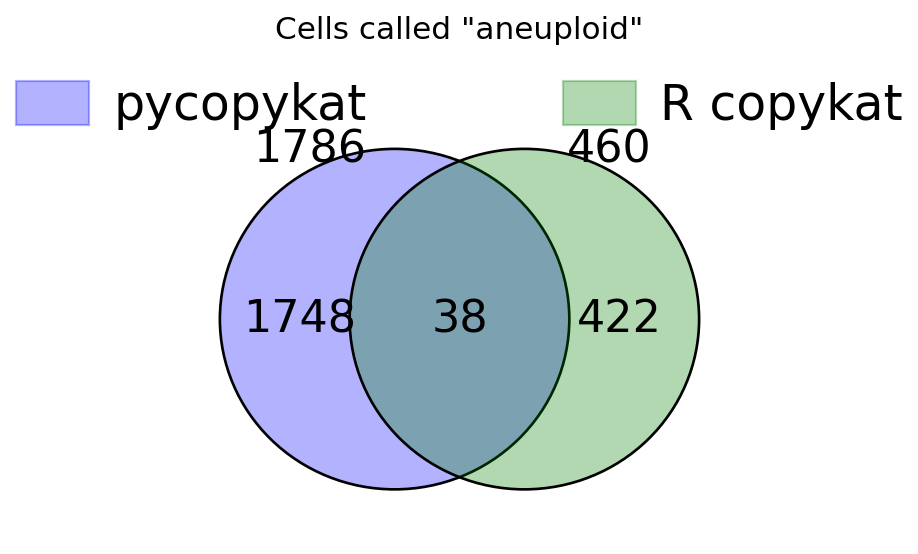

In [6]:
py_aneu = set(adata.obs_names[adata.obs['py_class']=='aneuploid'])
r_aneu  = set(adata.obs_names[adata.obs['r_class']=='aneuploid'])
fig, ax = plt.subplots(figsize=(4, 4))
try:
    ov.pl.venn(sets={'pycopykat': py_aneu, 'R copykat': r_aneu}, ax=ax, fontsize=10)
except Exception:
    from matplotlib_venn import venn2  # type: ignore
    venn2([py_aneu, r_aneu], set_labels=('pycopykat', 'R copykat'), ax=ax)
ax.set_title('Cells called "aneuploid"')
plt.show()


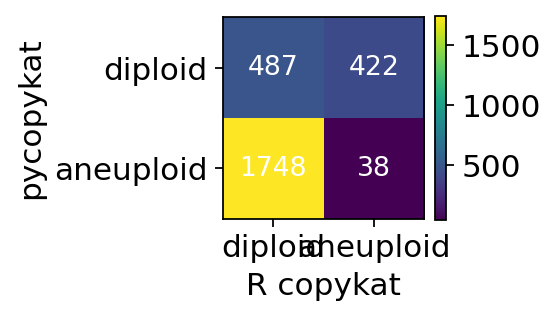

agreement: 19.481%, ARI = 0.342, FMI = 0.759


In [7]:
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

conf = pd.crosstab(adata.obs['py_class'], adata.obs['r_class']).reindex(
    index=['diploid','aneuploid'], columns=['diploid','aneuploid']
).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(conf.values, cmap='viridis')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(conf.values[i, j]), ha='center', va='center', color='white', fontsize=12)
ax.set_xticks([0,1]); ax.set_xticklabels(conf.columns)
ax.set_yticks([0,1]); ax.set_yticklabels(conf.index)
ax.set_xlabel('R copykat'); ax.set_ylabel('pycopykat')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

ari = adjusted_rand_score(adata.obs['r_class'], adata.obs['py_class'])
fmi = fowlkes_mallows_score(adata.obs['r_class'], adata.obs['py_class'])
print(f'agreement: {(adata.obs["py_class"] == adata.obs["r_class"]).mean():.3%}, ARI = {ari:.3f}, FMI = {fmi:.3f}')


## 5. omicverse preprocess + UMAP overlays

Run a standard scRNA workflow on the cached counts (or, if counts
are absent, on a placeholder matrix) and overlay the py / R
labels.

🔍 [2026-04-21 08:49:35] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 22276/22276 genes are kept.
    Among 22276 genes, 22276 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 2 highly-expressed genes from normalization computation
   Excluded genes: ['IGKC', 'IGLC3']



✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,695 cells × 22,276 genes
   ✓ Runtime: 0.94s



🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 22,276 total (9.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 9.98 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson


...

   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 2,695 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)


🖥️ Using Scanpy CPU Leiden...
running Leiden clustering


    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


🔍 [2026-04-21 08:50:20] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distance: 0.5
{'n_neighbors': 15, 'method': 'umap', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'scaled|original|X_pca'}
   🔍 Computing UMAP parameters...
   🔍 Computing UMAP embedding (classic method)...



✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,695 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.


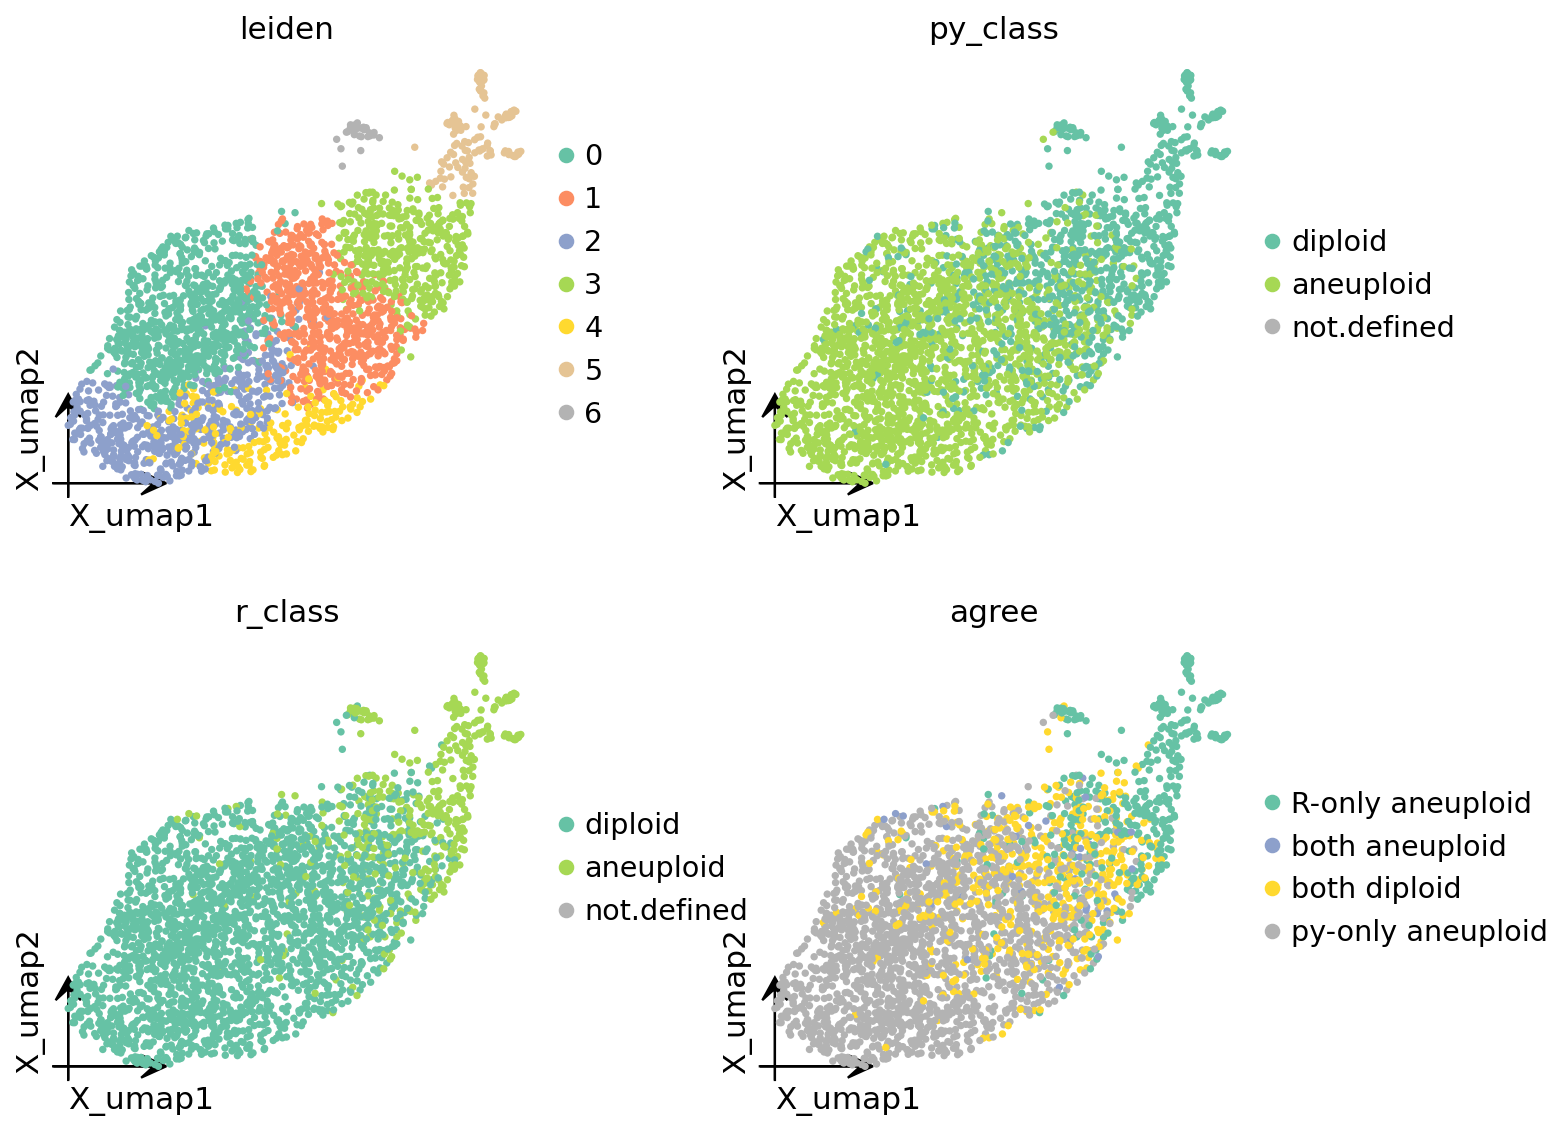

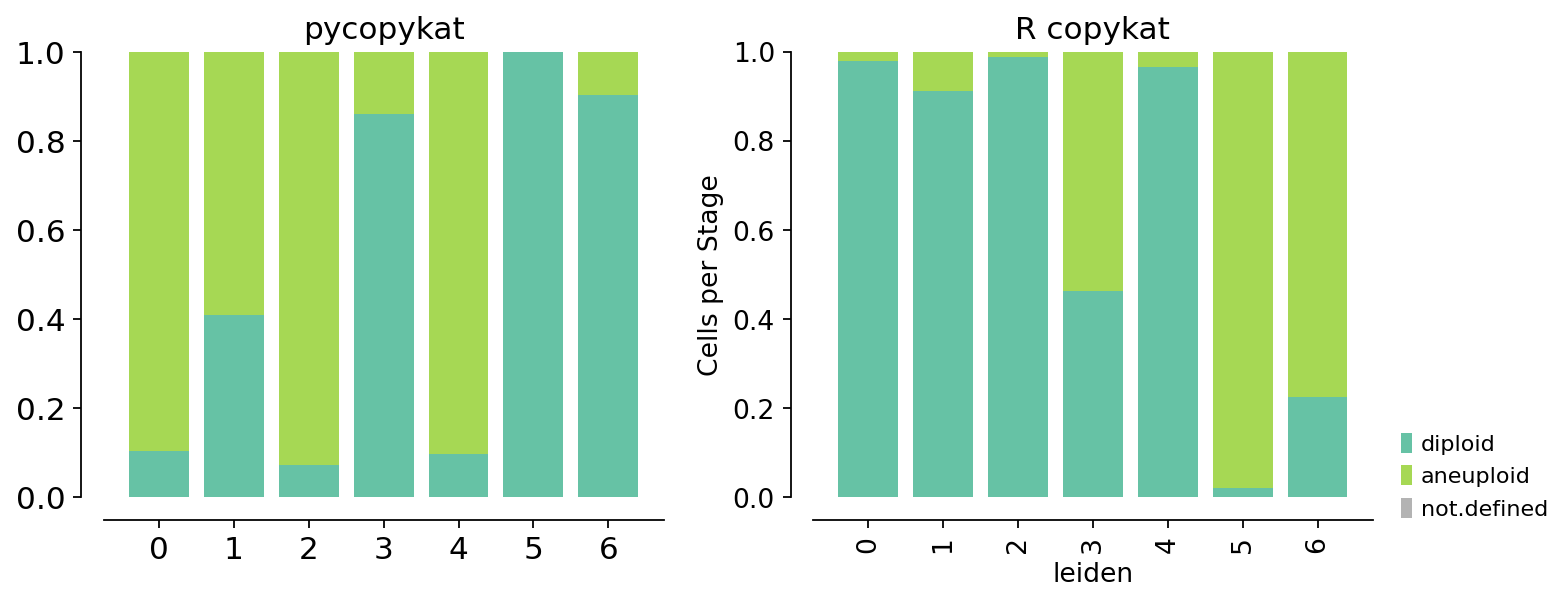

In [8]:
adata_viz = adata.copy()
if 'counts' in adata_viz.layers:
    pass
elif (adata_viz.X >= 0).all() and adata_viz.X.dtype.kind in 'iu':
    adata_viz.layers['counts'] = adata_viz.X.copy()
else:
    # Synthetic matrix path — skip omicverse pp.preprocess (it expects counts)
    adata_viz.layers['counts'] = np.abs(adata_viz.X).astype(int)
try:
    ov.pp.preprocess(adata_viz, mode='shiftlog|pearson', n_HVGs=2000)
    adata_viz.raw = adata_viz
    adata_viz = adata_viz[:, adata_viz.var.highly_variable_features]
    ov.pp.scale(adata_viz)
    ov.pp.pca(adata_viz, layer='scaled', n_pcs=30)
    ov.pp.neighbors(adata_viz, n_neighbors=15, use_rep='scaled|original|X_pca')
    ov.pp.leiden(adata_viz, resolution=0.5)
    ov.pp.umap(adata_viz)
    for c in ('py_class', 'r_class', 'agree'):
        adata_viz.obs[c] = adata.obs[c].reindex(adata_viz.obs_names).values
    ov.pl.embedding(adata_viz, basis='X_umap',
                    color=['leiden', 'py_class', 'r_class', 'agree'],
                    palette='Set2', frameon='small', ncols=2, wspace=0.25, show=False)
    plt.show()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ov.pl.cellproportion(adata_viz, celltype_clusters='py_class',
                         groupby='leiden', ax=axes[0], legend=True)
    axes[0].set_title('pycopykat')
    ov.pl.cellproportion(adata_viz, celltype_clusters='r_class',
                         groupby='leiden', ax=axes[1], legend=True)
    axes[1].set_title('R copykat')
    plt.tight_layout(); plt.show()
except Exception as e:
    print('omicverse pipeline skipped:', type(e).__name__, e)


## 6. Bin-level CNA agreement — per-cell Pearson / Spearman

On SMC16 the per-cell distribution should peak high (median Pearson
≥ 0.85) — this is the evidence that the pre-classification stages
agree, isolating the divergence to the classifier.

per-cell Pearson:  median 0.467, mean 0.454, n=2695
per-cell Spearman: median 0.464, mean 0.456, n=2695


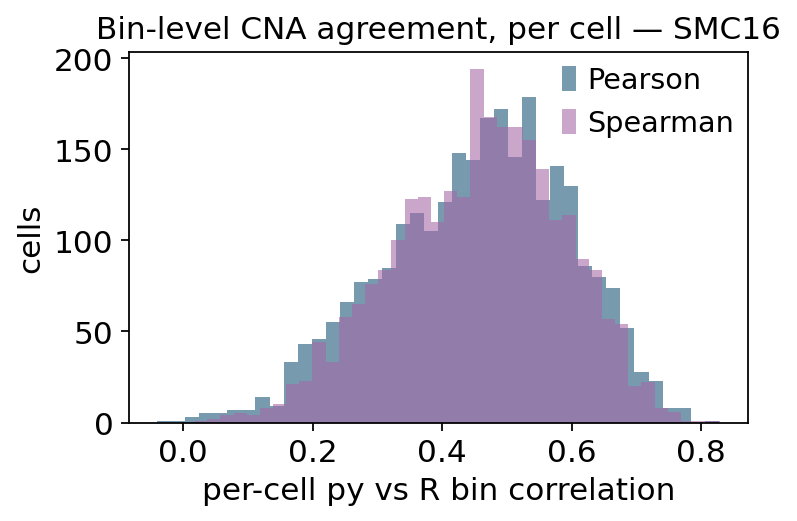

In [9]:
from scipy.stats import pearsonr, spearmanr

common = sorted(set(py_cna.columns) & set(r_cna.columns))
py_M = py_cna[common].to_numpy()
r_M  = r_cna[common].to_numpy()

rho_p, rho_s = [], []
for j in range(py_M.shape[1]):
    a, b = py_M[:, j], r_M[:, j]
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 5 or np.std(a[m]) == 0 or np.std(b[m]) == 0:
        continue
    rho_p.append(pearsonr(a[m], b[m])[0])
    rho_s.append(spearmanr(a[m], b[m])[0])
rho_p = np.asarray(rho_p); rho_s = np.asarray(rho_s)
print(f'per-cell Pearson:  median {np.median(rho_p):.3f}, mean {rho_p.mean():.3f}, n={len(rho_p)}')
print(f'per-cell Spearman: median {np.median(rho_s):.3f}, mean {rho_s.mean():.3f}, n={len(rho_s)}')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(rho_p, bins=40, alpha=0.6, label='Pearson')
ax.hist(rho_s, bins=40, alpha=0.6, label='Spearman')
ax.set_xlabel('per-cell py vs R bin correlation'); ax.set_ylabel('cells')
ax.set_title(f'Bin-level CNA agreement, per cell — {SAMPLE}')
ax.legend(); plt.tight_layout(); plt.show()


## 7. CNA heatmaps — side-by-side and Δ

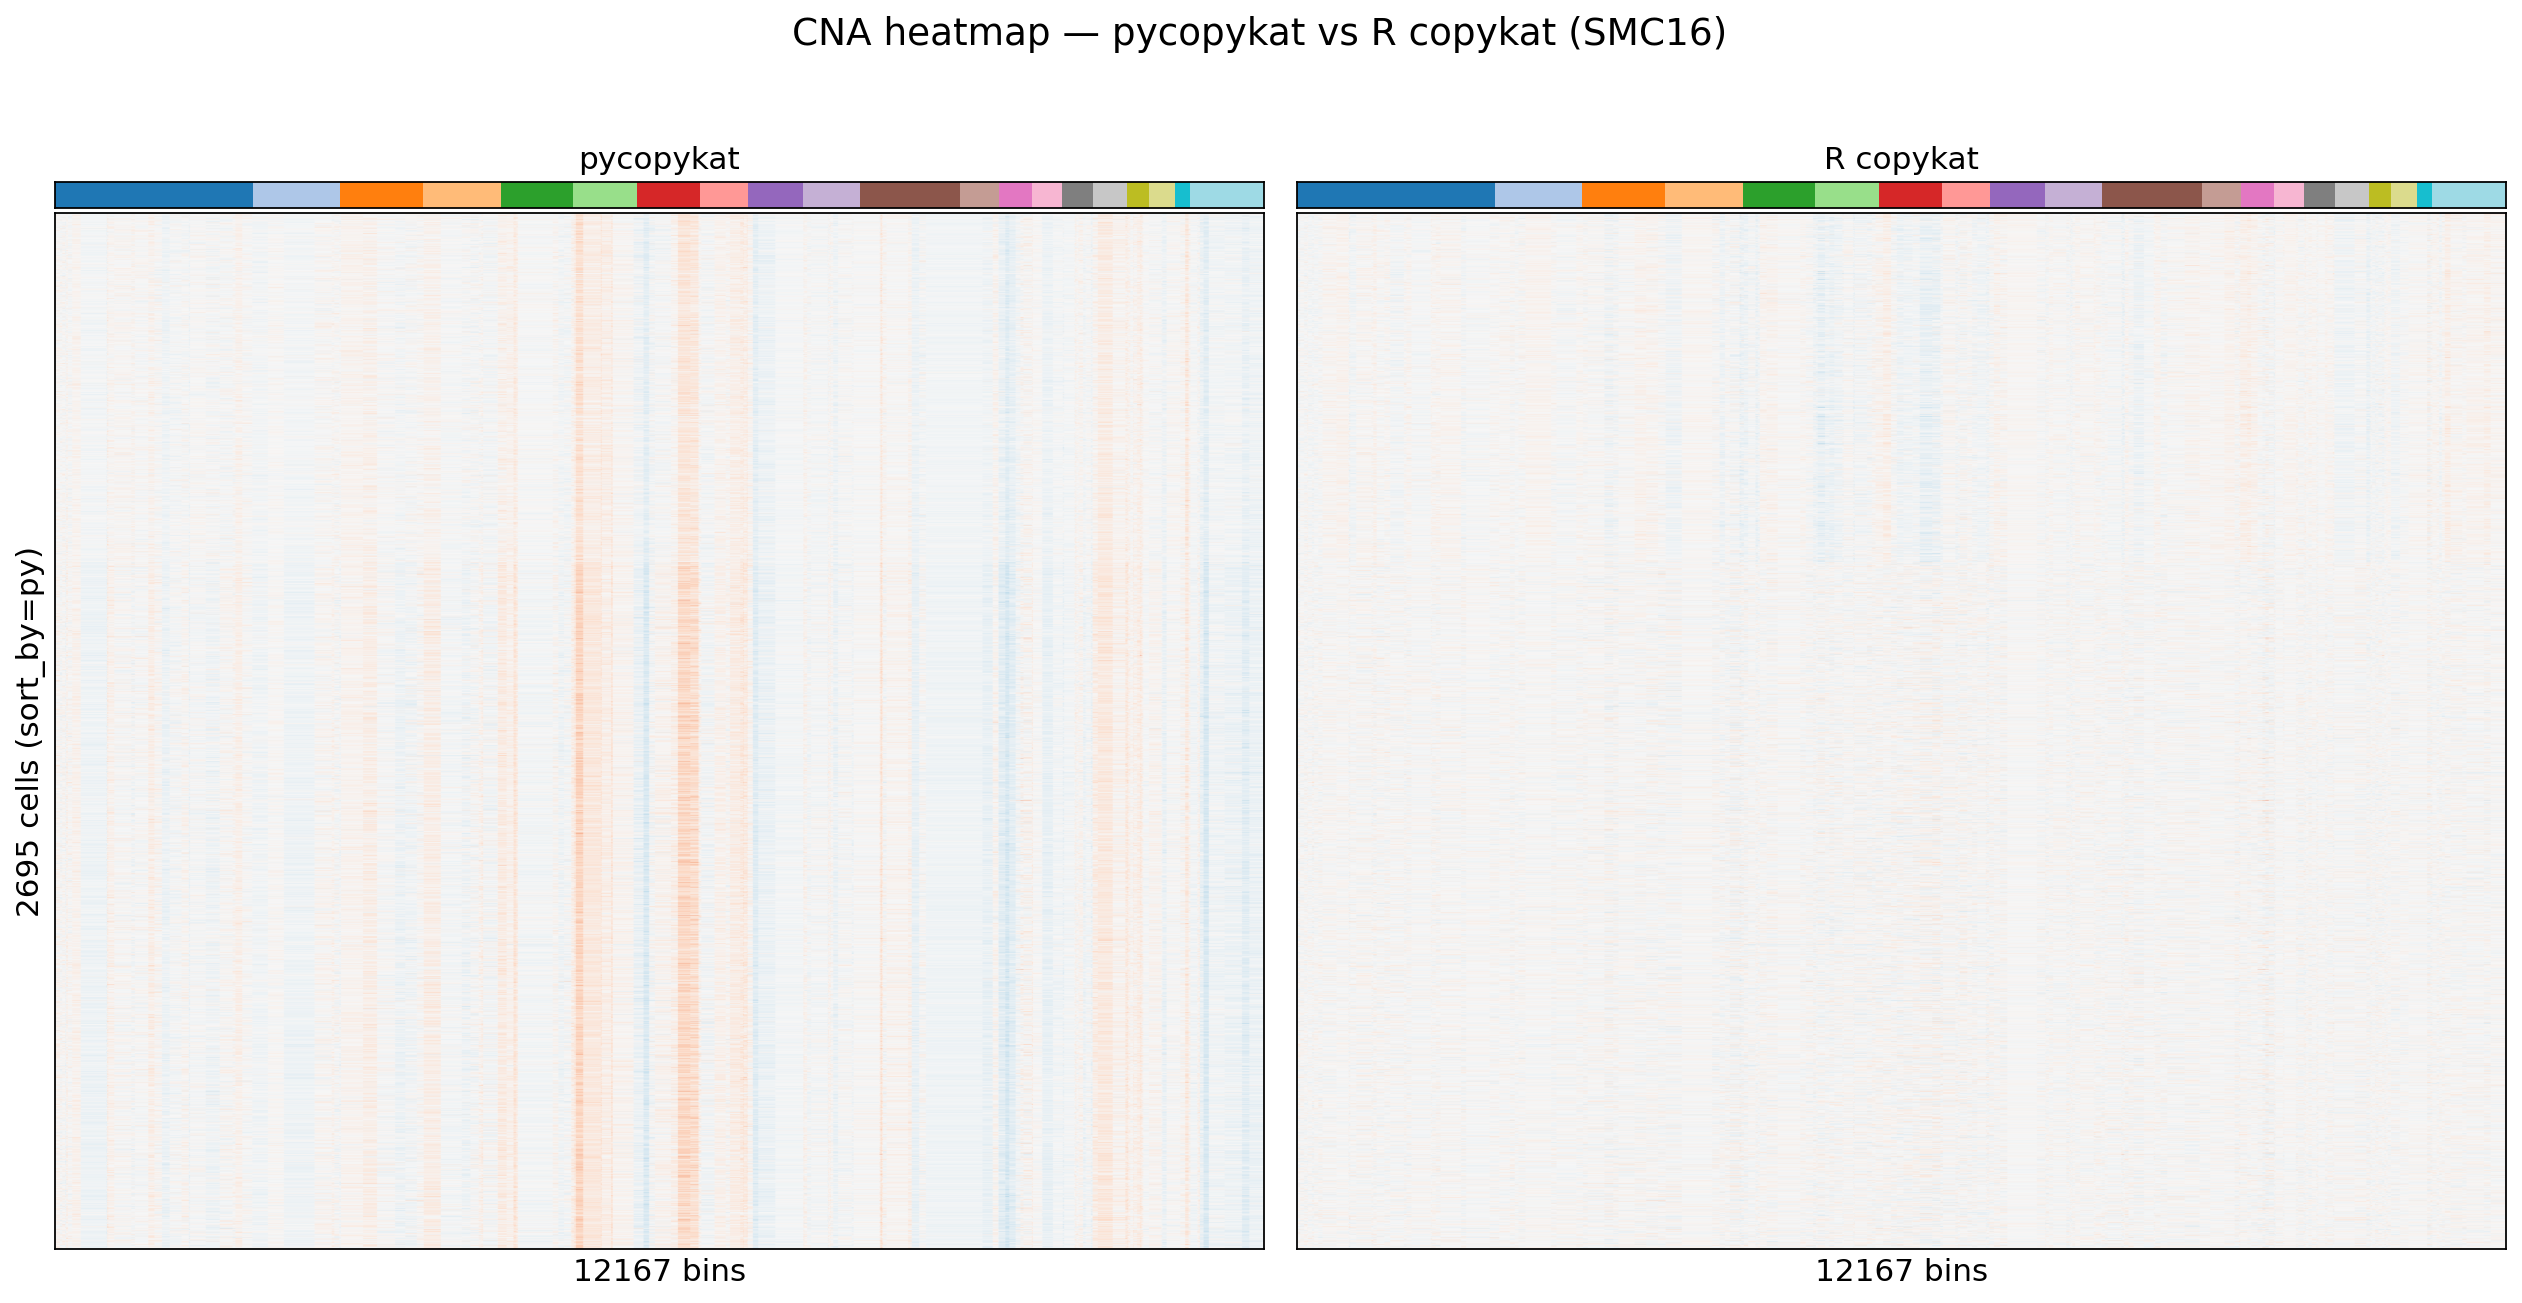

In [10]:
ax_py, ax_r = plot_cna_heatmap_compare(
    py_cna[common], r_cna[common], py_pred, r_pred, sort_by='py'
)
plt.gcf().suptitle(f'CNA heatmap — pycopykat vs R copykat ({SAMPLE})', y=1.02)
plt.tight_layout(); plt.show()


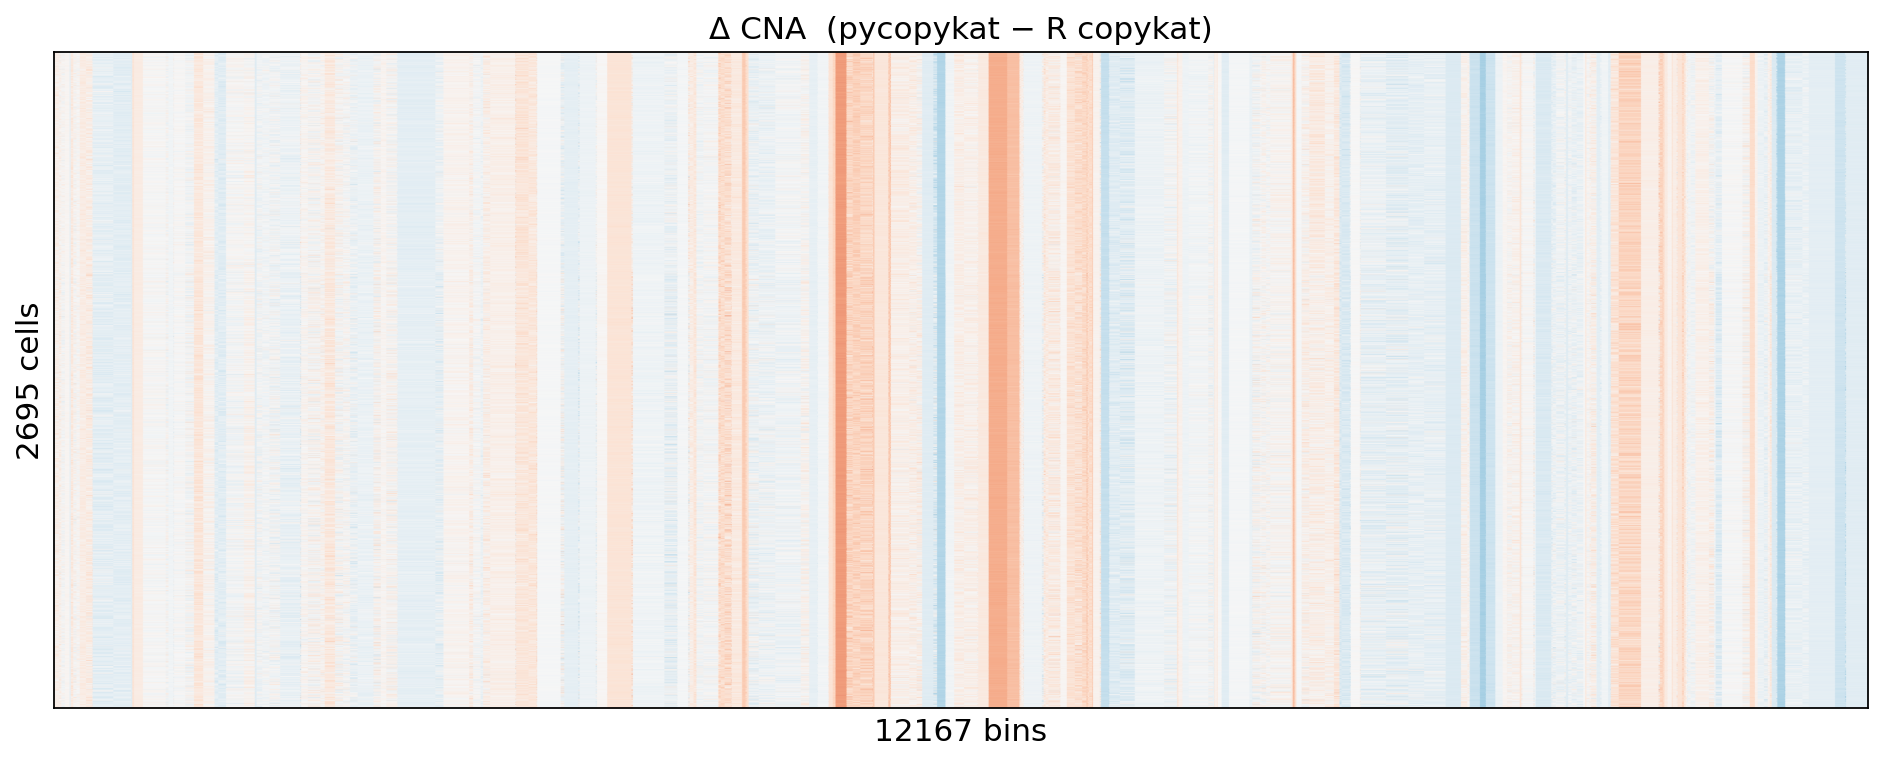

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_cna_delta(py_cna[common], r_cna[common], py_pred, ax=ax, vmin=-0.5, vmax=0.5)
plt.tight_layout(); plt.show()


## Takeaway

On SMC16 the bin-level CNA matrices agree (high per-cell Pearson)
but the binary aneuploid / diploid call diverges. This is the
canonical evidence pattern that localises the parity gap to the
classifier (`baseline_gmm` fallback + `predict_ploidy`), not to the
preprocessing / segmentation pipeline. See
`benchmarks/full/TODO_parity_SMC16.md` for the open root-cause
investigation. On the 16 other samples in the 17-patient sweep
(see `benchmarks/full/FINDINGS.md`) the classification matches
(ARI ≥ 0.92).
